# 02. Exploratory Data Analysis and Candidate Model Justification

## Explaining the COVID-19 Effect on Mental Health Search Behavior  
### EDA aligned with SARIMAX intervention modeling

This notebook uses the preprocessing outputs created by `01_Preprocessing.ipynb` and prepares the evidence needed for `03_Modeling_COVID_Period_Final.ipynb`.

The main EDA objective is not to choose the final model visually. Instead, EDA provides evidence for a reasonable candidate model set:

```text
Stationarity tests → d = 1
ACF/PACF short-lag behavior → p and q candidates
ACF/PACF seasonal spikes → SARIMA seasonal candidates with s = 12
COVID phase analysis → SARIMAX intervention variables
```


## A. Imports, Paths, and Shared Configuration

The COVID phase definition in this notebook must match both preprocessing and modeling.

| Phase | Period |
|---|---|
| Pre-COVID | 2004-01 to 2019-12 |
| COVID period | 2020-01 to 2023-05 |
| Post-COVID | 2023-06 to 2025-12 |


In [99]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("data")
EDA_OUTPUT_DIR = Path("data")
FIGURES_DIR = Path("figures")

EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "01_input.csv"
MODEL_INPUT_PATH = PROCESSED_DIR / "01_input_modeling.csv"

MENTAL_VARS = ["anxiety", "depression", "stress", "insomnia", "mental_disorder"]
MAIN_VAR = "anxiety"

PRE_COVID_END = pd.Timestamp("2019-12-01")
COVID_START = pd.Timestamp("2020-01-01")
COVID_END = pd.Timestamp("2023-05-01")
POST_COVID_START = pd.Timestamp("2023-06-01")

print("Input path:", INPUT_PATH)
print("Modeling input path:", MODEL_INPUT_PATH)
print("COVID period:", COVID_START.date(), "→", COVID_END.date())
print("Post-COVID starts:", POST_COVID_START.date())


Input path: data\01_input.csv
Modeling input path: data\01_input_modeling.csv
COVID period: 2020-01-01 → 2023-05-01
Post-COVID starts: 2023-06-01


## B. Load Cleaned Data and Validate Phase Structure

`input.csv` is the transparent cleaned EDA dataset.  
`input_modeling.csv` is the complete dataset used by the modeling notebook.

EDA primarily uses `input_modeling.csv` so that plots and statistics match the modeling sample exactly.


In [100]:
if not INPUT_PATH.exists():
    raise FileNotFoundError("Missing data/input.csv. Run 01_Preprocessing.ipynb first.")
if not MODEL_INPUT_PATH.exists():
    raise FileNotFoundError("Missing data/input_modeling.csv. Run 01_Preprocessing.ipynb first.")

input_df = pd.read_csv(INPUT_PATH)
input_df["date"] = pd.to_datetime(input_df["date"])

model_df = pd.read_csv(MODEL_INPUT_PATH)
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values(["country", "date"]).reset_index(drop=True)

COUNTRIES = sorted(model_df["country"].unique())

print("input.csv shape:", input_df.shape)
print("input.csv remaining NaN:", int(input_df[MENTAL_VARS].isna().sum().sum()))
print("input_modeling.csv shape:", model_df.shape)
print("input_modeling.csv remaining NaN:", int(model_df[MENTAL_VARS].isna().sum().sum()))
print("Countries:", COUNTRIES)
print("Date range:", model_df["date"].min().date(), "→", model_df["date"].max().date())

display(model_df.head())


input.csv shape: (1584, 7)
input.csv remaining NaN: 6
input_modeling.csv shape: (1584, 20)
input_modeling.csv remaining NaN: 0
Countries: ['Australia', 'Canada', 'Ireland', 'New_Zealand', 'UK', 'US']
Date range: 2004-01-01 → 2025-12-01


,date,country,anxiety,depression,stress,insomnia,mental_disorder,anxiety_was_imputed,depression_was_imputed,stress_was_imputed,insomnia_was_imputed,mental_disorder_was_imputed,year,month,time_index,analysis_phase,covid_period,covid_trend,post_covid_period,post_covid_trend
0,2004-01-01,Australia,27.0,55.0,28.0,6.0,16.0,0,0,0,0,0,2004,1,0,pre_covid,0,0,0,0
1,2004-02-01,Australia,31.0,63.0,34.0,9.0,28.0,0,0,0,0,0,2004,2,1,pre_covid,0,0,0,0
2,2004-03-01,Australia,32.0,82.0,45.0,9.0,40.0,0,0,0,0,0,2004,3,2,pre_covid,0,0,0,0
3,2004-04-01,Australia,33.0,73.0,45.0,5.0,34.0,0,0,0,0,0,2004,4,3,pre_covid,0,0,0,0
4,2004-05-01,Australia,33.0,87.0,49.0,8.0,38.0,0,0,0,0,0,2004,5,4,pre_covid,0,0,0,0


In [101]:
phase_check = (
    model_df
    .groupby(["country", "analysis_phase"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_months=("date", "size"),
        covid_period_sum=("covid_period", "sum"),
        covid_trend_max=("covid_trend", "max"),
        post_covid_period_sum=("post_covid_period", "sum"),
        post_covid_trend_max=("post_covid_trend", "max"),
    )
    .reset_index()
)

display(phase_check)
phase_check.to_csv(EDA_OUTPUT_DIR / "02_eda_phase_validation.csv", index=False)


,country,analysis_phase,start_date,end_date,n_months,covid_period_sum,covid_trend_max,post_covid_period_sum,post_covid_trend_max
0,Australia,covid_period,2020-01-01,2023-05-01,41,41,41,0,0
1,Australia,post_covid,2023-06-01,2025-12-01,31,0,0,31,31
2,Australia,pre_covid,2004-01-01,2019-12-01,192,0,0,0,0
3,Canada,covid_period,2020-01-01,2023-05-01,41,41,41,0,0
4,Canada,post_covid,2023-06-01,2025-12-01,31,0,0,31,31
5,Canada,pre_covid,2004-01-01,2019-12-01,192,0,0,0,0
6,Ireland,covid_period,2020-01-01,2023-05-01,41,41,41,0,0
7,Ireland,post_covid,2023-06-01,2025-12-01,31,0,0,31,31
8,Ireland,pre_covid,2004-01-01,2019-12-01,192,0,0,0,0
9,New_Zealand,covid_period,2020-01-01,2023-05-01,41,41,41,0,0


## C. Descriptive Statistics

This section summarizes the distribution of the five Google Trends variables by country.

Important interpretation rule: Google Trends indices are normalized search-interest measures. They should not be interpreted as clinical prevalence rates.


In [102]:
desc = (
    model_df
    .groupby("country")[MENTAL_VARS]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

desc.to_csv(EDA_OUTPUT_DIR / "02_descriptive_statistics_by_country.csv")
display(desc)


anxiety                                           depression  \
              count       mean        std   min median    max      count   
country                                                                    
Australia       264  59.401515  25.314256  21.0   60.0  100.0        264   
Canada          264  59.867424  24.923179  26.0   59.0  100.0        264   
Ireland         264  53.831439  26.545055  12.0   51.5  100.0        264   
New_Zealand     264  58.109848  26.413343  18.0   54.0  100.0        264   
UK              264  53.041667  29.893254  14.0   49.5  100.0        264   
US              264  57.219697  24.935755  22.0   51.5  100.0        264   

                                        ...  insomnia                    \
                  mean        std  min  ...       std  min median   max   
country                                 ...                               
Australia    37.284091  21.308497  4.0  ...  1.752765  5.0    9.0  13.0   
Canada       35.041667  15.919300  7.0  ...  1.614401  7.0   10.0  16.0   
Ireland      31.159091  17.636520  3.0  ...  3.067925  4.0   10.0  21.0   
New_Zealand  38.784091  22.413390  3.0  ...  2.106909  5.0   11.0  16.0   
UK           27.215909  14.025329  3.0  ...  2.211115  4.0    8.0  15.0   
US           30.303030  13.929720  5.0  ...  2.094372  6.0   10.0  15.0   

            mental_disorder                                           
                      count       mean        std   min median   max  
country                                                               
Australia               264  26.147727  11.009025  10.0   23.0  69.0  
Canada                  264  23.757576   9.199621  10.0   21.0  70.0  
Ireland                 264  17.426136   7.759775   7.0   15.0  51.0  
New_Zealand             264  25.087121  11.075441   9.0   23.0  72.0  
UK                      264  20.640152  10.457012   8.0   17.0  71.0  
US                      264  21.534091   7.520237  11.0   19.0  52.0  

[6 rows x 30 columns]

## D. Long-Term Trend Overview

The figure below shows the main variable, `anxiety`, across all six countries.

The shaded region marks the COVID period from 2020-01 to 2023-05. The dashed line marks the beginning of the post-COVID period in 2023-06.


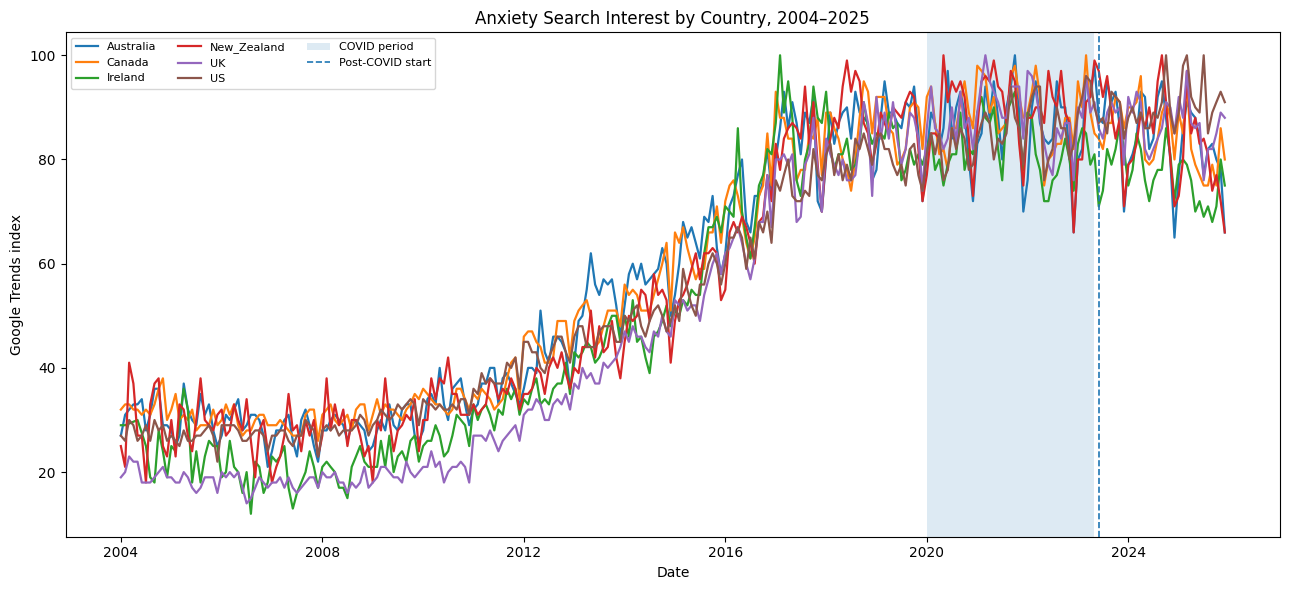

In [103]:
fig, ax = plt.subplots(figsize=(13, 6))
for country in COUNTRIES:
    s = model_df.loc[model_df["country"].eq(country), ["date", MAIN_VAR]]
    ax.plot(s["date"], s[MAIN_VAR], label=country, linewidth=1.6)

ax.axvspan(COVID_START, COVID_END, alpha=0.15, label="COVID period")
ax.axvline(POST_COVID_START, linestyle="--", linewidth=1.2, label="Post-COVID start")
ax.set_title("Anxiety Search Interest by Country, 2004–2025")
ax.set_xlabel("Date")
ax.set_ylabel("Google Trends index")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_eda_anxiety_trend_covid_period.png", dpi=300, bbox_inches="tight")
plt.show()


## E. Phase Comparison: Pre-COVID, COVID Period, Post-COVID

This table compares average search interest across the three research phases.

The comparison is descriptive. It does not control for autocorrelation, trend, or seasonality. SARIMAX in the modeling notebook handles those dynamics.


In [104]:
phase_summary = (
    model_df
    .groupby(["country", "analysis_phase"])[MENTAL_VARS]
    .mean()
    .reset_index()
)

# Pivot for phase comparisons.
phase_pivot = phase_summary.pivot(index="country", columns="analysis_phase", values=MAIN_VAR).reset_index()
phase_pivot["covid_minus_pre"] = phase_pivot["covid_period"] - phase_pivot["pre_covid"]
phase_pivot["post_minus_pre"] = phase_pivot["post_covid"] - phase_pivot["pre_covid"]
phase_pivot["covid_pct_vs_pre"] = 100 * phase_pivot["covid_minus_pre"] / phase_pivot["pre_covid"]
phase_pivot["post_pct_vs_pre"] = 100 * phase_pivot["post_minus_pre"] / phase_pivot["pre_covid"]

phase_summary.to_csv(EDA_OUTPUT_DIR / "02_phase_mean_summary_all_variables.csv", index=False)
phase_pivot.to_csv(EDA_OUTPUT_DIR / "02_phase_mean_summary_anxiety.csv", index=False)

display(phase_pivot)


analysis_phase,country,covid_period,post_covid,pre_covid,covid_minus_pre,post_minus_pre,covid_pct_vs_pre,post_pct_vs_pre
0,Australia,86.707317,84.064516,49.588542,37.118775,34.475974,74.853533,69.524074
1,Canada,88.829268,84.645161,49.682292,39.146977,34.962870,78.794627,70.372900
2,Ireland,82.365854,76.967742,44.002604,38.363249,32.965138,87.184043,74.916334
3,New_Zealand,89.073171,84.064516,47.307292,41.765879,36.757224,88.286346,77.698856
4,UK,88.560976,86.838710,40.000000,48.560976,46.838710,121.402439,117.096774
5,US,85.365854,90.161290,45.890625,39.475229,44.270665,86.020246,96.469955


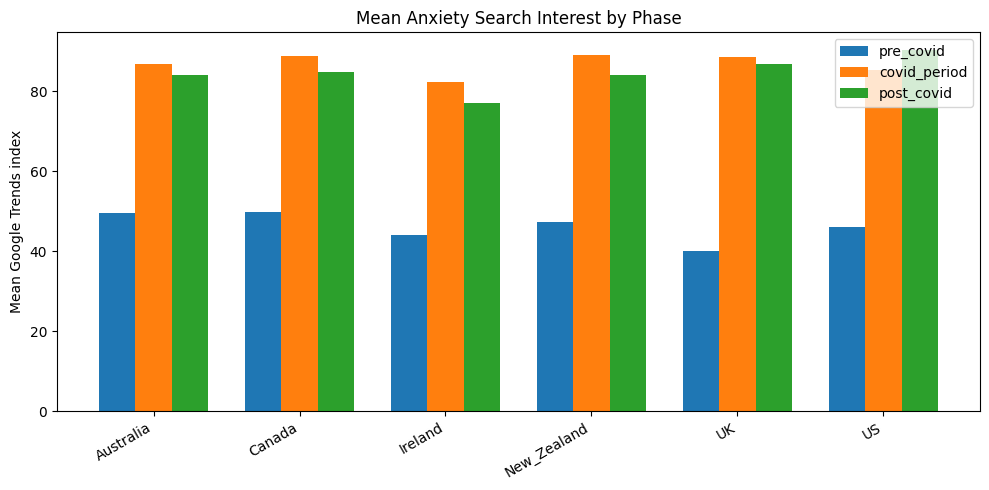

In [105]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = phase_summary.loc[phase_summary["analysis_phase"].isin(["pre_covid", "covid_period", "post_covid"])]
plot_df = plot_df.loc[:, ["country", "analysis_phase", MAIN_VAR]]

phase_order = ["pre_covid", "covid_period", "post_covid"]
x = np.arange(len(COUNTRIES))
width = 0.25

for i, phase in enumerate(phase_order):
    vals = [plot_df.query("country == @c and analysis_phase == @phase")[MAIN_VAR].iloc[0] for c in COUNTRIES]
    ax.bar(x + (i - 1) * width, vals, width=width, label=phase)

ax.set_xticks(x)
ax.set_xticklabels(COUNTRIES, rotation=30, ha="right")
ax.set_ylabel("Mean Google Trends index")
ax.set_title("Mean Anxiety Search Interest by Phase")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_eda_anxiety_phase_means.png", dpi=300, bbox_inches="tight")
plt.show()


## F. Structural Break Tests

This section performs Chow-style structural break tests using a regression with:

- time trend
- monthly seasonal dummies

Two break dates are tested:

1. COVID onset: 2020-01
2. Post-COVID transition: 2023-06

These tests motivate the SARIMAX intervention structure. They do not replace the SARIMAX model.


In [106]:
def design_matrix(dates: pd.Series, time_index: pd.Series) -> pd.DataFrame:
    X = pd.DataFrame({"time_index": time_index.astype(float).values})
    month_dummies = pd.get_dummies(pd.to_datetime(dates).dt.month, prefix="m", drop_first=True).astype(float)
    X = pd.concat([X.reset_index(drop=True), month_dummies.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X, has_constant="add")
    return X.astype(float)


def chow_test(data: pd.DataFrame, y_col: str, break_date: pd.Timestamp) -> dict:
    d = data[["date", "time_index", y_col]].dropna().copy()
    before = d["date"] < break_date
    after = d["date"] >= break_date

    if before.sum() < 20 or after.sum() < 20:
        return {"F": np.nan, "p_value": np.nan, "n_before": int(before.sum()), "n_after": int(after.sum())}

    y = d[y_col].astype(float).values
    X = design_matrix(d["date"], d["time_index"])
    k = X.shape[1]

    pooled = sm.OLS(y, X).fit()
    sse_pooled = np.sum(pooled.resid ** 2)

    y1 = d.loc[before, y_col].astype(float).values
    X1 = design_matrix(d.loc[before, "date"], d.loc[before, "time_index"])
    fit1 = sm.OLS(y1, X1).fit()
    sse1 = np.sum(fit1.resid ** 2)

    y2 = d.loc[after, y_col].astype(float).values
    X2 = design_matrix(d.loc[after, "date"], d.loc[after, "time_index"])
    fit2 = sm.OLS(y2, X2).fit()
    sse2 = np.sum(fit2.resid ** 2)

    n1, n2 = len(y1), len(y2)
    numerator = (sse_pooled - (sse1 + sse2)) / k
    denominator = (sse1 + sse2) / (n1 + n2 - 2 * k)
    F = numerator / denominator if denominator > 0 else np.nan
    p = 1 - stats.f.cdf(F, k, n1 + n2 - 2 * k) if np.isfinite(F) else np.nan

    return {"F": F, "p_value": p, "n_before": n1, "n_after": n2}

break_tests = []
for country in COUNTRIES:
    g = model_df.loc[model_df["country"].eq(country)].copy()
    for var in MENTAL_VARS:
        for break_name, break_date in {
            "covid_onset_2020_01": COVID_START,
            "post_covid_transition_2023_06": POST_COVID_START,
        }.items():
            out = chow_test(g, var, break_date)
            break_tests.append({
                "country": country,
                "variable": var,
                "break_name": break_name,
                "break_date": break_date,
                **out,
                "significant_5pct": bool(out["p_value"] < 0.05) if pd.notna(out["p_value"]) else False,
            })

break_results = pd.DataFrame(break_tests)
break_results.to_csv(EDA_OUTPUT_DIR / "02_chow_structural_break_tests.csv", index=False)

display(break_results.query("variable == 'anxiety'").sort_values(["break_name", "country"]))


,country,variable,break_name,break_date,F,p_value,n_before,n_after,significant_5pct
0,Australia,anxiety,covid_onset_2020_01,2020-01-01,10.857422,0.000000e+00,192,72,True
10,Canada,anxiety,covid_onset_2020_01,2020-01-01,9.955117,1.110223e-16,192,72,True
20,Ireland,anxiety,covid_onset_2020_01,2020-01-01,10.723881,0.000000e+00,192,72,True
30,New_Zealand,anxiety,covid_onset_2020_01,2020-01-01,7.918246,4.284351e-13,192,72,True
40,UK,anxiety,covid_onset_2020_01,2020-01-01,6.594573,1.011842e-10,192,72,True
50,US,anxiety,covid_onset_2020_01,2020-01-01,2.257886,8.192882e-03,192,72,True
1,Australia,anxiety,post_covid_transition_2023_06,2023-06-01,8.031352,2.705614e-13,233,31,True
11,Canada,anxiety,post_covid_transition_2023_06,2023-06-01,8.467544,4.651834e-14,233,31,True
21,Ireland,anxiety,post_covid_transition_2023_06,2023-06-01,7.743160,8.744117e-13,233,31,True
31,New_Zealand,anxiety,post_covid_transition_2023_06,2023-06-01,6.634923,8.546353e-11,233,31,True


## G. Seasonality Analysis

Monthly SARIMA terms are justified only if the data show seasonal dependence. This section calculates month-of-year averages and seasonal coefficient of variation.

Seasonal CV is descriptive:

\[
CV = \frac{\text{standard deviation of monthly means}}{\text{mean of monthly means}}
\]

Higher values indicate stronger average month-of-year variation.


In [107]:
season_rows = []
for country in COUNTRIES:
    g = model_df.loc[model_df["country"].eq(country)].copy()
    for var in MENTAL_VARS:
        monthly_means = g.groupby("month")[var].mean()
        season_rows.append({
            "country": country,
            "variable": var,
            "seasonal_mean": monthly_means.mean(),
            "seasonal_sd": monthly_means.std(),
            "seasonal_cv_pct": 100 * monthly_means.std() / monthly_means.mean(),
        })

seasonality = pd.DataFrame(season_rows)
seasonality.to_csv(EDA_OUTPUT_DIR / "02_seasonality_cv_by_country_variable.csv", index=False)

display(seasonality.sort_values("seasonal_cv_pct", ascending=False).head(15))

monthly_pattern = (
    model_df
    .groupby(["variable", "month"])["value"].mean()
    .reset_index()
) if {"variable", "value"}.issubset(model_df.columns) else None


,country,variable,seasonal_mean,seasonal_sd,seasonal_cv_pct
4,Australia,mental_disorder,26.147727,4.338171,16.591008
9,Canada,mental_disorder,23.757576,3.638808,15.316410
14,Ireland,mental_disorder,17.426136,2.659261,15.260186
1,Australia,depression,37.284091,5.421079,14.539926
19,New_Zealand,mental_disorder,25.087121,3.506753,13.978300
12,Ireland,stress,26.174242,3.621189,13.834934
2,Australia,stress,27.545455,3.765776,13.671133
16,New_Zealand,depression,38.784091,5.179611,13.354989
7,Canada,stress,28.890152,3.762306,13.022796
17,New_Zealand,stress,30.378788,3.809876,12.541236


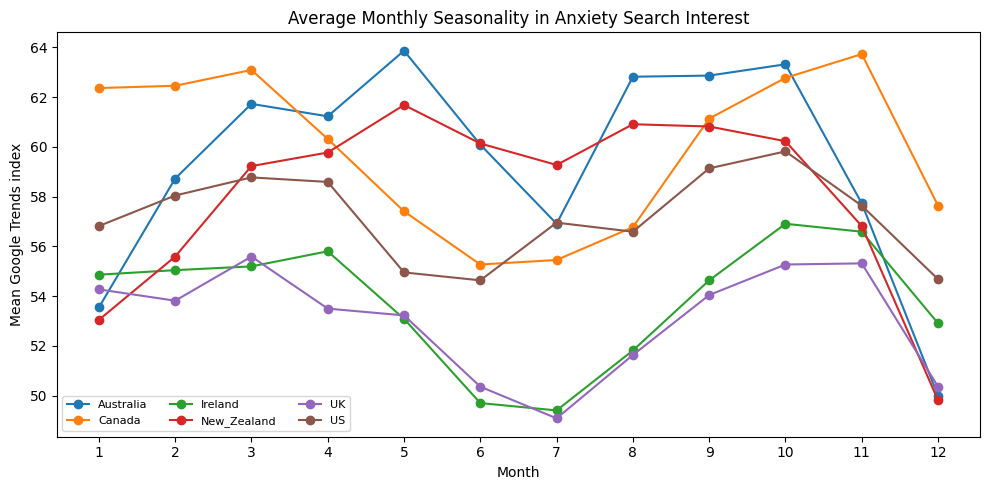

In [108]:
# Plot average monthly pattern for anxiety by country.
fig, ax = plt.subplots(figsize=(10, 5))
for country in COUNTRIES:
    monthly = model_df.loc[model_df["country"].eq(country)].groupby("month")[MAIN_VAR].mean()
    ax.plot(monthly.index, monthly.values, marker="o", linewidth=1.5, label=country)

ax.set_title("Average Monthly Seasonality in Anxiety Search Interest")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Google Trends index")
ax.set_xticks(range(1, 13))
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_eda_anxiety_monthly_seasonality.png", dpi=300, bbox_inches="tight")
plt.show()


## H. Stationarity Tests

ARIMA/SARIMA requires a differencing decision. This section applies:

- ADF test: null hypothesis = unit root / non-stationary
- KPSS test: null hypothesis = stationary

Decision rule used for modeling:

- If level series are mostly non-stationary and first differences are more stationary, use `d = 1`.
- ACF/PACF are then inspected on first-differenced anxiety.


In [109]:
def adf_pvalue(x):
    x = pd.Series(x).dropna()
    if len(x) < 20 or x.nunique() <= 1:
        return np.nan
    try:
        return adfuller(x, autolag="AIC")[1]
    except Exception:
        return np.nan


def kpss_pvalue(x):
    x = pd.Series(x).dropna()
    if len(x) < 20 or x.nunique() <= 1:
        return np.nan
    try:
        return kpss(x, regression="c", nlags="auto")[1]
    except Exception:
        return np.nan

stationarity_rows = []
for country in COUNTRIES:
    g = model_df.loc[model_df["country"].eq(country)].set_index("date")
    for var in MENTAL_VARS:
        level = g[var]
        diff1 = g[var].diff()
        stationarity_rows.append({
            "country": country,
            "variable": var,
            "series": "level",
            "adf_pvalue": adf_pvalue(level),
            "kpss_pvalue": kpss_pvalue(level),
        })
        stationarity_rows.append({
            "country": country,
            "variable": var,
            "series": "diff1",
            "adf_pvalue": adf_pvalue(diff1),
            "kpss_pvalue": kpss_pvalue(diff1),
        })

stationarity = pd.DataFrame(stationarity_rows)
stationarity["adf_stationary_5pct"] = stationarity["adf_pvalue"] < 0.05
stationarity["kpss_stationary_5pct"] = stationarity["kpss_pvalue"] > 0.05
stationarity.to_csv(EDA_OUTPUT_DIR / "02_stationarity_adf_kpss.csv", index=False)

display(stationarity.query("variable == 'anxiety'").sort_values(["country", "series"]))


,country,variable,series,adf_pvalue,kpss_pvalue,adf_stationary_5pct,kpss_stationary_5pct
1,Australia,anxiety,diff1,0.045783,0.10,True,True
0,Australia,anxiety,level,0.732823,0.01,False,False
11,Canada,anxiety,diff1,0.053490,0.10,False,True
10,Canada,anxiety,level,0.701250,0.01,False,False
21,Ireland,anxiety,diff1,0.010687,0.10,True,True
20,Ireland,anxiety,level,0.727214,0.01,False,False
31,New_Zealand,anxiety,diff1,0.000023,0.10,True,True
30,New_Zealand,anxiety,level,0.765406,0.01,False,False
41,UK,anxiety,diff1,0.011205,0.10,True,True
40,UK,anxiety,level,0.820722,0.01,False,False


## I. ACF/PACF of First-Differenced Anxiety

The ACF/PACF plots are used to justify the candidate orders in the modeling notebook.

Key interpretation rules:

| Pattern | Candidate implication |
|---|---|
| ACF spike around lag 1 | MA(1), so include `ARIMA(0,1,1)` |
| PACF short-lag signal | AR term, so include `ARIMA(1,1,1)` or `ARIMA(2,1,1)` |
| ACF/PACF both show short-lag dependence | mixed ARMA, so include `ARIMA(1,1,1)` |
| seasonal spikes at 12, 24, 36 | SARIMA with `s = 12` |
| uncertain seasonal differencing | test both `D = 0` and `D = 1` |

The final model is still selected in `03_Modeling` by validation errors, test errors, information criteria, and residual diagnostics.


In [110]:
acf_summary_rows = []
max_lag = 36

for country in COUNTRIES:
    y = (
        model_df.loc[model_df["country"].eq(country)]
        .set_index("date")[MAIN_VAR]
        .asfreq("MS")
    )
    y_diff = y.diff().dropna()
    n = len(y_diff)
    threshold = 1.96 / np.sqrt(n)

    acf_vals = acf(y_diff, nlags=max_lag, fft=False)
    pacf_vals = pacf(y_diff, nlags=max_lag, method="ywm")

    sig_acf_lags = [lag for lag in range(1, max_lag + 1) if abs(acf_vals[lag]) > threshold]
    sig_pacf_lags = [lag for lag in range(1, max_lag + 1) if abs(pacf_vals[lag]) > threshold]
    seasonal_acf = [lag for lag in [12, 24, 36] if lag in sig_acf_lags]
    seasonal_pacf = [lag for lag in [12, 24, 36] if lag in sig_pacf_lags]

    acf_summary_rows.append({
        "country": country,
        "n_diff_obs": n,
        "significance_threshold": threshold,
        "significant_acf_lags": sig_acf_lags,
        "significant_pacf_lags": sig_pacf_lags,
        "seasonal_acf_lags_12_24_36": seasonal_acf,
        "seasonal_pacf_lags_12_24_36": seasonal_pacf,
        "lag1_acf_significant": 1 in sig_acf_lags,
        "lag1_pacf_significant": 1 in sig_pacf_lags,
    })

acf_summary = pd.DataFrame(acf_summary_rows)
acf_summary.to_csv(EDA_OUTPUT_DIR / "02_acf_pacf_anxiety_diff1_significant_lags.csv", index=False)
display(acf_summary)


,country,n_diff_obs,significance_threshold,significant_acf_lags,significant_pacf_lags,seasonal_acf_lags_12_24_36,seasonal_pacf_lags_12_24_36,lag1_acf_significant,lag1_pacf_significant
0,Australia,263,0.120859,"[2, 3, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 18,...","[2, 3, 4, 9, 10, 11, 12, 13, 15, 17, 23, 24, 36]","[12, 24, 36]","[12, 24, 36]",False,False
1,Canada,263,0.120859,"[1, 3, 9, 12, 15, 21, 23, 24, 27, 33, 36]","[1, 3, 4, 9, 10, 11, 12, 13, 15, 23, 24, 25, 36]","[12, 24, 36]","[12, 24, 36]",True,True
2,Ireland,263,0.120859,"[1, 4, 12, 15, 22, 24, 30, 36]","[1, 2, 3, 4, 9, 12, 13, 14, 22, 25]","[12, 24, 36]",[12],True,True
3,New_Zealand,263,0.120859,"[1, 3, 12, 24, 27, 29, 36]","[1, 3, 4, 6, 8, 9, 10, 11, 12, 13, 16, 25, 26]","[12, 24, 36]",[12],True,True
4,UK,263,0.120859,"[1, 3, 9, 11, 12, 13, 15, 21, 23, 24, 27, 36]","[1, 3, 4, 10, 11, 12, 13, 24, 26]","[12, 24, 36]","[12, 24]",True,True
5,US,263,0.120859,"[1, 3, 6, 8, 10, 12, 14, 16, 18, 22, 24, 28, 3...","[1, 2, 3, 4, 5, 9, 10, 11, 12, 13]","[12, 24, 36]",[12],True,True


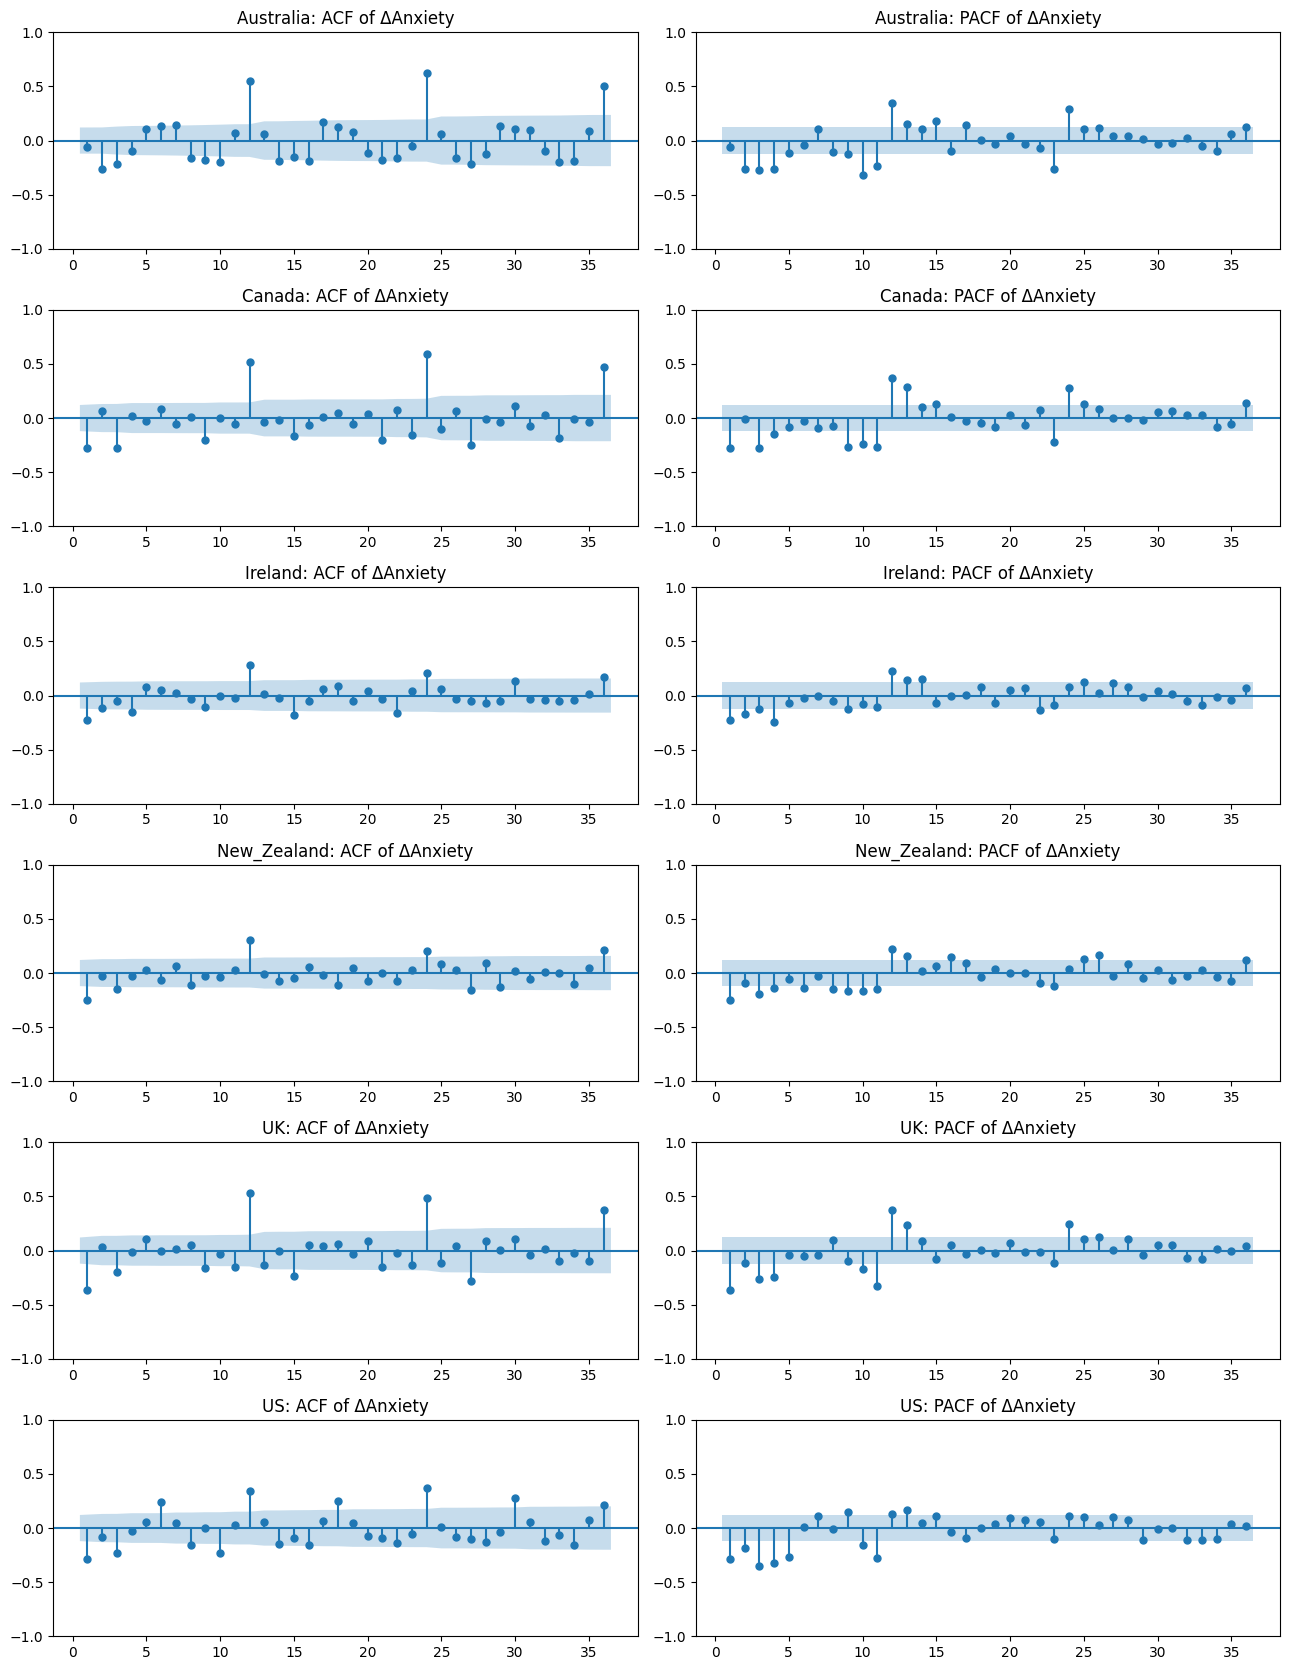

In [111]:
fig, axes = plt.subplots(len(COUNTRIES), 2, figsize=(13, 2.8 * len(COUNTRIES)))

for i, country in enumerate(COUNTRIES):
    y = (
        model_df.loc[model_df["country"].eq(country)]
        .set_index("date")[MAIN_VAR]
        .asfreq("MS")
    )
    y_diff = y.diff().dropna()

    plot_acf(y_diff, lags=36, ax=axes[i, 0], zero=False)
    plot_pacf(y_diff, lags=36, ax=axes[i, 1], method="ywm", zero=False)
    axes[i, 0].set_title(f"{country}: ACF of ΔAnxiety")
    axes[i, 1].set_title(f"{country}: PACF of ΔAnxiety")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_eda_anxiety_acf_pacf_diff1_anxiety.png", dpi=300, bbox_inches="tight")
plt.show()


## J. ACF/PACF Interpretation and Modeling Candidate Orders

This section explicitly connects EDA findings to the candidate orders used in `03_Modeling_COVID_Period_Final.ipynb`.

The candidate set is common across all countries. This avoids country-specific cherry-picking and keeps the comparative analysis consistent.


In [112]:
# Country-level interpretation summary.
suggestions = {
    "Australia": {
        "acf": "Lag-1 short-run dependence with seasonal spikes around 12/24/36",
        "pacf": "Short-lag AR signal with seasonal signal near 12/24",
        "implication": "Use low-order ARIMA and monthly SARIMA with s=12",
    },
    "Canada": {
        "acf": "Strong short-run dependence and clear seasonal spikes at 12/24/36",
        "pacf": "Short-lag AR signal with seasonal signal near 12/24",
        "implication": "Use low-order ARIMA and monthly SARIMA with s=12",
    },
    "Ireland": {
        "acf": "Weaker/noisier short-run dependence with mild seasonal spikes",
        "pacf": "Weak short-lag AR signal and mild seasonal signal",
        "implication": "Keep low-order candidates; avoid overly large p/q",
    },
    "New_Zealand": {
        "acf": "Lag-1 dependence with seasonal spikes around 12/24",
        "pacf": "Short-lag AR signal around 1–2 and seasonal signal near 12",
        "implication": "Include ARIMA(2,1,1) and SARIMA candidates",
    },
    "UK": {
        "acf": "Strong lag-1 dependence and strong seasonal spikes at 12/24/36",
        "pacf": "Short-lag AR signal and seasonal dependence near 12/24",
        "implication": "Strong reason to test SARIMA with s=12",
    },
    "US": {
        "acf": "Lag-1 dependence with seasonal/mid-lag spikes around 12/24/30/36",
        "pacf": "Short-lag AR signal and less clean seasonal dependence",
        "implication": "Include ARIMA(1,1,2) and SARIMA candidates",
    },
}

suggestions_df = pd.DataFrame([
    {"country": c, **info} for c, info in suggestions.items()
])

ARIMA_ORDERS = [
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
]

SARIMA_SPECS = [
    ((0, 1, 1), (0, 0, 1, 12)),
    ((1, 1, 1), (0, 0, 1, 12)),
    ((0, 1, 1), (1, 0, 0, 12)),
    ((1, 1, 1), (1, 0, 0, 12)),
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
]

candidate_logic = pd.DataFrame([
    {
        "eda_finding": "First-differenced anxiety is more stationary than levels",
        "modeling_decision": "Use d = 1 in ARIMA/SARIMA candidates",
    },
    {
        "eda_finding": "ACF shows lag-1 dependence",
        "modeling_decision": "Include ARIMA(0,1,1)",
    },
    {
        "eda_finding": "ACF and PACF both show short-lag signals",
        "modeling_decision": "Include ARIMA(1,1,1)",
    },
    {
        "eda_finding": "Some countries show lag 1–2 dependence/noisier short-run pattern",
        "modeling_decision": "Include ARIMA(2,1,1) and ARIMA(1,1,2)",
    },
    {
        "eda_finding": "ACF/PACF show seasonal spikes at 12/24/36",
        "modeling_decision": "Use SARIMA seasonal period s = 12",
    },
    {
        "eda_finding": "Seasonal differencing is plausible but not guaranteed",
        "modeling_decision": "Compare D = 0 and D = 1",
    },
    {
        "eda_finding": "Seasonal AR and MA behavior are both plausible",
        "modeling_decision": "Test seasonal AR (1,D,0,12) and seasonal MA (0,D,1,12)",
    },
])

arima_specs_df = pd.DataFrame({"model_class": "ARIMA", "order": [str(o) for o in ARIMA_ORDERS], "seasonal_order": "(0, 0, 0, 0)"})
sarima_specs_df = pd.DataFrame({"model_class": "SARIMA/SARIMAX", "order": [str(o) for o, s in SARIMA_SPECS], "seasonal_order": [str(s) for o, s in SARIMA_SPECS]})
model_candidate_specs = pd.concat([arima_specs_df, sarima_specs_df], ignore_index=True)

suggestions_df.to_csv(EDA_OUTPUT_DIR / "02_acf_pacf_country_suggestions_anxiety.csv", index=False)
candidate_logic.to_csv(EDA_OUTPUT_DIR / "02_acf_pacf_to_model_candidate_logic.csv", index=False)
model_candidate_specs.to_csv(EDA_OUTPUT_DIR / "02_model_candidate_specs_for_03_modeling.csv", index=False)

display(suggestions_df)
display(candidate_logic)
display(model_candidate_specs)


,country,acf,pacf,implication
0,Australia,Lag-1 short-run dependence with seasonal spike...,Short-lag AR signal with seasonal signal near ...,Use low-order ARIMA and monthly SARIMA with s=12
1,Canada,Strong short-run dependence and clear seasonal...,Short-lag AR signal with seasonal signal near ...,Use low-order ARIMA and monthly SARIMA with s=12
2,Ireland,Weaker/noisier short-run dependence with mild ...,Weak short-lag AR signal and mild seasonal signal,Keep low-order candidates; avoid overly large p/q
3,New_Zealand,Lag-1 dependence with seasonal spikes around 1...,Short-lag AR signal around 1–2 and seasonal si...,"Include ARIMA(2,1,1) and SARIMA candidates"
4,UK,Strong lag-1 dependence and strong seasonal sp...,Short-lag AR signal and seasonal dependence ne...,Strong reason to test SARIMA with s=12
5,US,Lag-1 dependence with seasonal/mid-lag spikes ...,Short-lag AR signal and less clean seasonal de...,"Include ARIMA(1,1,2) and SARIMA candidates"


,eda_finding,modeling_decision
0,First-differenced anxiety is more stationary t...,Use d = 1 in ARIMA/SARIMA candidates
1,ACF shows lag-1 dependence,"Include ARIMA(0,1,1)"
2,ACF and PACF both show short-lag signals,"Include ARIMA(1,1,1)"
3,Some countries show lag 1–2 dependence/noisier...,"Include ARIMA(2,1,1) and ARIMA(1,1,2)"
4,ACF/PACF show seasonal spikes at 12/24/36,Use SARIMA seasonal period s = 12
5,Seasonal differencing is plausible but not gua...,Compare D = 0 and D = 1
6,Seasonal AR and MA behavior are both plausible,"Test seasonal AR (1,D,0,12) and seasonal MA (0..."


,model_class,order,seasonal_order
0,ARIMA,"(0, 1, 1)","(0, 0, 0, 0)"
1,ARIMA,"(1, 1, 1)","(0, 0, 0, 0)"
2,ARIMA,"(2, 1, 1)","(0, 0, 0, 0)"
3,ARIMA,"(1, 1, 2)","(0, 0, 0, 0)"
4,SARIMA/SARIMAX,"(0, 1, 1)","(0, 0, 1, 12)"
5,SARIMA/SARIMAX,"(1, 1, 1)","(0, 0, 1, 12)"
6,SARIMA/SARIMAX,"(0, 1, 1)","(1, 0, 0, 12)"
7,SARIMA/SARIMAX,"(1, 1, 1)","(1, 0, 0, 12)"
8,SARIMA/SARIMAX,"(0, 1, 1)","(0, 1, 1, 12)"
9,SARIMA/SARIMAX,"(1, 1, 1)","(0, 1, 1, 12)"


## K. EDA Summary for Modeling

Core findings used by the modeling notebook:

1. `anxiety` is the main analysis variable.
2. The modeling sample uses 2004-01 to 2025-12.
3. COVID period is defined as 2020-01 to 2023-05.
4. Post-COVID period begins in 2023-06.
5. Stationarity tests motivate first differencing, so ARIMA/SARIMA candidates use `d = 1`.
6. ACF/PACF of first-differenced anxiety show lag-1 short-run dependence, motivating `ARIMA(0,1,1)` and `ARIMA(1,1,1)`.
7. Some countries show lag 1–2/noisier short-lag behavior, motivating `ARIMA(2,1,1)` and `ARIMA(1,1,2)`.
8. Seasonal spikes at 12, 24, and 36 motivate SARIMA candidates with `s = 12`.
9. Seasonal differencing is treated as an empirical candidate, not an assumption, so both `D = 0` and `D = 1` are tested.
10. Final model selection is deferred to `03_Modeling_COVID_Period_Final.ipynb`, using validation errors, test errors, AIC/BIC, and residual diagnostics.


In [113]:
eda_outputs = [
    EDA_OUTPUT_DIR / "02_descriptive_statistics_by_country.csv",
    EDA_OUTPUT_DIR / "02_phase_mean_summary_all_variables.csv",
    EDA_OUTPUT_DIR / "02_phase_mean_summary_anxiety.csv",
    EDA_OUTPUT_DIR / "02_chow_structural_break_tests.csv",
    EDA_OUTPUT_DIR / "02_seasonality_cv_by_country_variable.csv",
    EDA_OUTPUT_DIR / "02_stationarity_adf_kpss.csv",
    EDA_OUTPUT_DIR / "02_acf_pacf_anxiety_diff1_significant_lags.csv",
    EDA_OUTPUT_DIR / "02_acf_pacf_country_suggestions_anxiety.csv",
    EDA_OUTPUT_DIR / "02_acf_pacf_to_model_candidate_logic.csv",
    EDA_OUTPUT_DIR / "02_model_candidate_specs_for_03_modeling.csv",
]

fig_outputs = [
    FIGURES_DIR / "02_eda_anxiety_trend_covid_period.png",
    FIGURES_DIR / "02_eda_anxiety_phase_means.png",
    FIGURES_DIR / "02_eda_anxiety_monthly_seasonality.png",
    FIGURES_DIR / "02_eda_anxiety_acf_pacf_diff1_anxiety.png",
]

checklist = pd.DataFrame({
    "file": [str(p) for p in eda_outputs + fig_outputs],
    "exists": [p.exists() for p in eda_outputs + fig_outputs],
})

display(checklist)

if not checklist["exists"].all():
    raise FileNotFoundError("Some expected EDA outputs were not created.")

print("EDA completed successfully and is aligned with 03_Modeling_COVID_Period_Final.ipynb.")


,file,exists
0,data\02_descriptive_statistics_by_country.csv,True
1,data\02_phase_mean_summary_all_variables.csv,True
2,data\02_phase_mean_summary_anxiety.csv,True
3,data\02_chow_structural_break_tests.csv,True
4,data\02_seasonality_cv_by_country_variable.csv,True
5,data\02_stationarity_adf_kpss.csv,True
6,data\02_acf_pacf_anxiety_diff1_significant_lag...,True
7,data\02_acf_pacf_country_suggestions_anxiety.csv,True
8,data\02_acf_pacf_to_model_candidate_logic.csv,True
9,data\02_model_candidate_specs_for_03_modeling.csv,True


EDA completed successfully and is aligned with 03_Modeling_COVID_Period_Final.ipynb.
